In [6]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

In [7]:
# 加载 sklearn 自带 MNIST（digits）
digits = load_digits()
X = digits.data          # shape = (1797, 64)
y = digits.target        # labels: 0–9

print("Dataset shape:", X.shape)
print("Labels:", set(y))

Dataset shape: (1797, 64)
Labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)}


In [8]:
mask = (y == 2) | (y == 5)
X25 = X[mask]
y25 = y[mask]

print("2 vs 5 dataset size:", X25.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X25, y25, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mlp_25 = MLPClassifier(
    hidden_layer_sizes=(50,),     # 一个隐藏层 50 个节点
    solver='adam',                # 更稳定
    learning_rate_init=0.001,
    max_iter=300,
    random_state=0,
    verbose=False
)

mlp_25.fit(X_train, y_train)

pred = mlp_25.predict(X_test)
acc_25 = accuracy_score(y_test, pred)

print("Accuracy (digit 2 vs 5):", acc_25)
print(classification_report(y_test, pred))

2 vs 5 dataset size: (359, 64)
Accuracy (digit 2 vs 5): 1.0
              precision    recall  f1-score   support

           2       1.00      1.00      1.00        34
           5       1.00      1.00      1.00        38

    accuracy                           1.00        72
   macro avg       1.00      1.00      1.00        72
weighted avg       1.00      1.00      1.00        72



In [9]:
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler_full = StandardScaler()
X_train_full = scaler_full.fit_transform(X_train_full)
X_test_full = scaler_full.transform(X_test_full)

mlp_full = MLPClassifier(
    hidden_layer_sizes=(100, 100),   # 两层隐藏层
    solver='adam',                   # 最稳定
    learning_rate_init=0.001,
    max_iter=300,
    random_state=0,
    verbose=False
)

mlp_full.fit(X_train_full, y_train_full)

pred_full = mlp_full.predict(X_test_full)
acc_full = accuracy_score(y_test_full, pred_full)

print("Multi-class Test Accuracy:", acc_full)
print(classification_report(y_test_full, pred_full))



Multi-class Test Accuracy: 0.9777777777777777
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.97      1.00      0.98        28
           2       1.00      1.00      1.00        33
           3       0.97      0.97      0.97        34
           4       1.00      1.00      1.00        46
           5       0.96      0.96      0.96        47
           6       0.97      0.97      0.97        35
           7       1.00      0.97      0.99        34
           8       0.97      0.97      0.97        30
           9       0.95      0.95      0.95        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



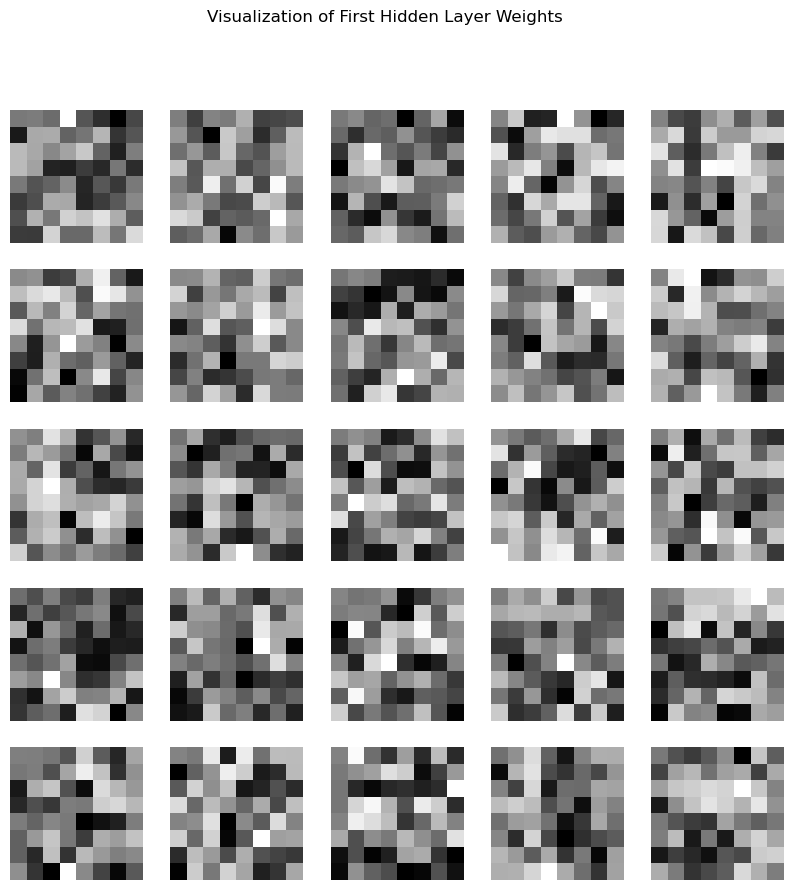

In [10]:
weights = mlp_full.coefs_[0].T   # shape (hidden_nodes, 64)

plt.figure(figsize=(10, 10))
for i in range(25):  # 显示前25个隐藏神经元
    plt.subplot(5, 5, i+1)
    plt.imshow(weights[i].reshape(8, 8), cmap='gray')
    plt.axis('off')

plt.suptitle("Visualization of First Hidden Layer Weights")
plt.show()